In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv('/content/Employee_Attrition_DataSet.csv')
data.head()

,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No


In [3]:
data.shape

(10000, 14)

In [4]:
data.columns

Index(['EmployeeID', 'Age', 'Department', 'JobLevel', 'YearsAtCompany',
       'MonthlyIncome', 'JobSatisfaction', 'WorkLifeBalance', 'OverTime',
       'DistanceFromHome', 'PromotionLast5Years', 'PerformanceRating',
       'TrainingHoursLastYear', 'Attrition'],
      dtype='object')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             10000 non-null  object 
 1   Age                    10000 non-null  int64  
 2   Department             10000 non-null  object 
 3   JobLevel               10000 non-null  int64  
 4   YearsAtCompany         10000 non-null  int64  
 5   MonthlyIncome          10000 non-null  int64  
 6   JobSatisfaction        10000 non-null  int64  
 7   WorkLifeBalance        10000 non-null  int64  
 8   OverTime               10000 non-null  object 
 9   DistanceFromHome       10000 non-null  float64
 10  PromotionLast5Years    10000 non-null  object 
 11  PerformanceRating      10000 non-null  int64  
 12  TrainingHoursLastYear  10000 non-null  int64  
 13  Attrition              10000 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 1.1+ M

In [6]:
data.describe()

,Age,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,DistanceFromHome,PerformanceRating,TrainingHoursLastYear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,37.693500,2.380800,7.788400,8967.918800,3.362100,2.761500,9.91074,2.603800,14.993100
std,9.376457,1.141368,7.141941,3500.745748,1.059951,0.893027,6.97463,0.737889,3.886227
min,22.000000,1.000000,0.000000,3000.000000,1.000000,1.000000,1.00000,1.000000,2.000000
25%,31.000000,1.000000,2.000000,6043.500000,3.000000,2.000000,4.70000,2.000000,12.000000
50%,37.000000,2.000000,6.000000,8670.000000,3.000000,3.000000,8.30000,3.000000,15.000000
75%,44.000000,3.000000,12.000000,11484.000000,4.000000,3.000000,13.40000,3.000000,18.000000
max,60.000000,5.000000,35.000000,21410.000000,5.000000,4.000000,50.00000,4.000000,31.000000


In [7]:
data.isnull().sum()

,0
EmployeeID,0
Age,0
Department,0
JobLevel,0
YearsAtCompany,0
MonthlyIncome,0
JobSatisfaction,0
WorkLifeBalance,0
OverTime,0
DistanceFromHome,0


In [8]:
data['Attrition'].value_counts()

,count
Attrition,
No,9097
Yes,903


In [9]:
# remove employee id
data.drop('EmployeeID', axis=1, inplace=True)

In [10]:
# unique
data['Department'].unique()

array(['Sales', 'Finance', 'HR', 'IT', 'Engineering', 'Operations',
       'Marketing'], dtype=object)

In [11]:

le = LabelEncoder()

data['Department'] = le.fit_transform(data['Department'])
data['OverTime'] = le.fit_transform(data['OverTime'])
data['PromotionLast5Years'] = le.fit_transform(data['PromotionLast5Years'])
data['Attrition'] = le.fit_transform(data['Attrition'])

In [12]:
data

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,42,6,3,9,9866,4,1,0,24.5,1,4,19,0
1,36,6,3,7,8958,3,3,0,10.0,0,2,13,0
2,44,6,4,16,11716,4,3,0,4.0,0,4,13,0
3,53,1,4,30,17061,5,3,0,7.1,0,3,20,0
4,35,2,2,4,5738,2,3,0,8.4,0,2,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,51,4,4,28,14510,4,1,0,14.0,0,3,17,0
9996,22,0,1,0,5659,3,3,1,25.3,0,3,19,1
9997,30,6,1,0,4223,3,4,1,15.8,0,2,20,0
9998,42,0,2,2,7990,5,3,0,5.7,0,3,25,0


EDA

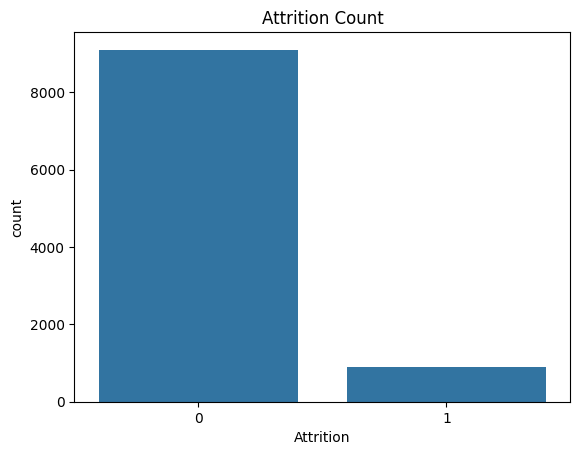

In [13]:
sns.countplot(x='Attrition', data=data)
plt.title("Attrition Count")
plt.show()

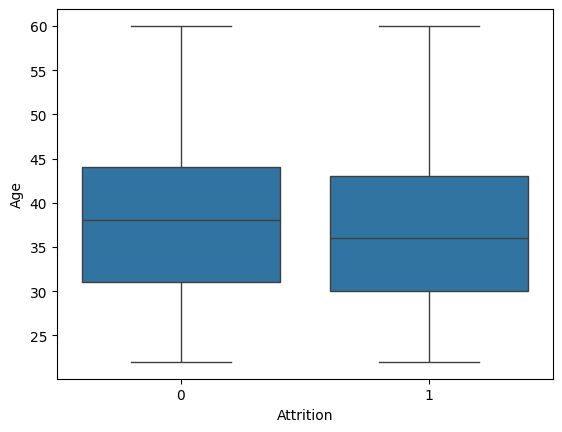

In [14]:
sns.boxplot(x='Attrition', y='Age', data=data)
plt.show()

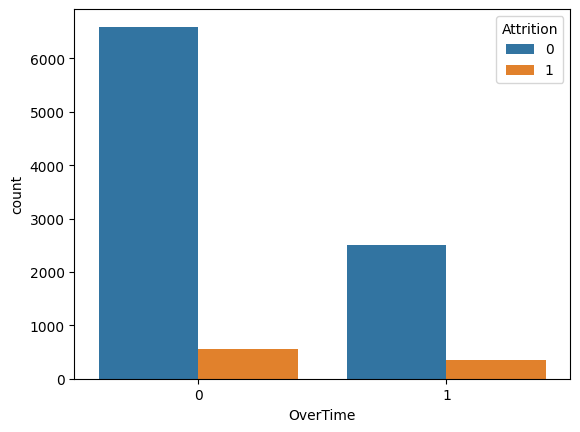

In [15]:
sns.countplot(x='OverTime', hue='Attrition', data=data)
plt.show()

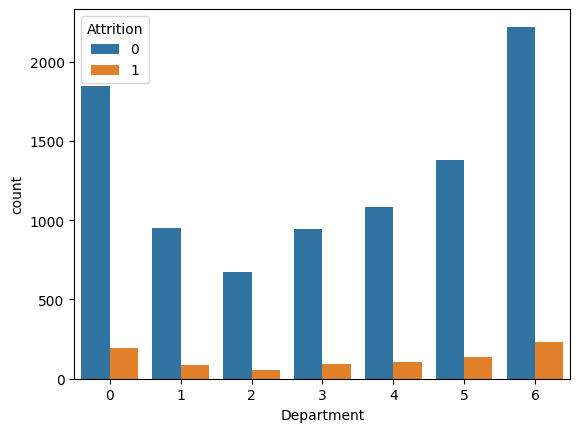

In [16]:
sns.countplot(x='Department', hue='Attrition', data=data)
plt.show()

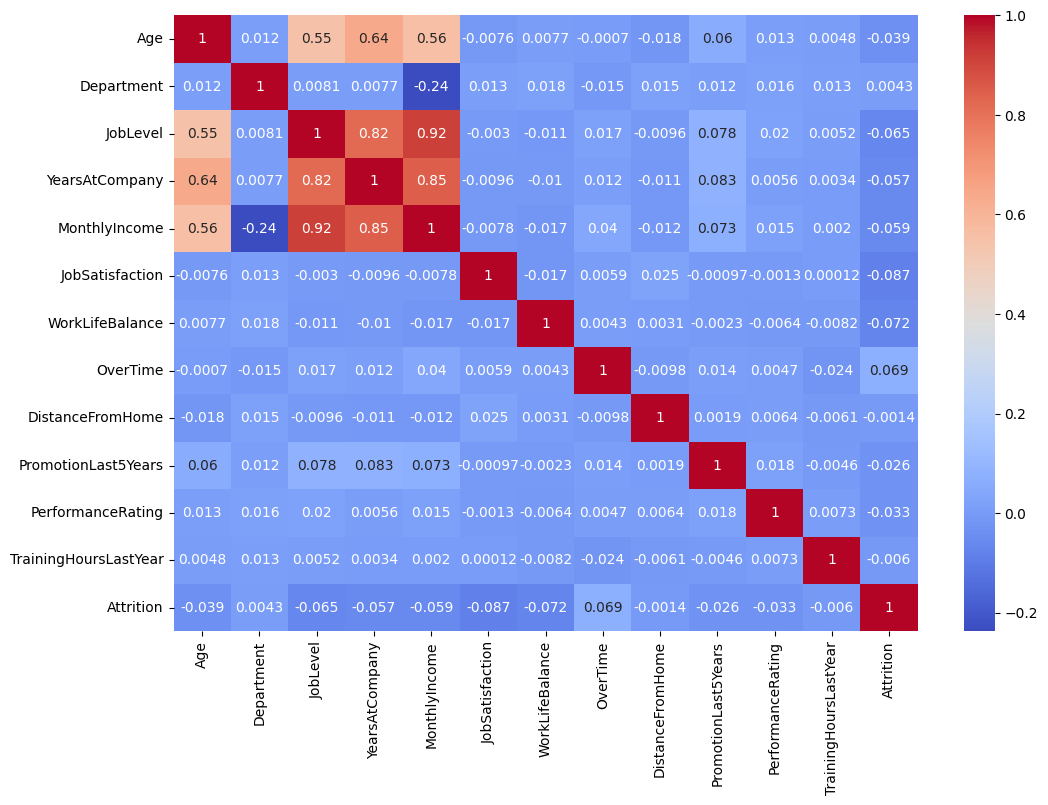

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

Model Training

In [18]:
X = data.drop('Attrition', axis=1)
y = data['Attrition']

In [19]:
X

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear
0,42,6,3,9,9866,4,1,0,24.5,1,4,19
1,36,6,3,7,8958,3,3,0,10.0,0,2,13
2,44,6,4,16,11716,4,3,0,4.0,0,4,13
3,53,1,4,30,17061,5,3,0,7.1,0,3,20
4,35,2,2,4,5738,2,3,0,8.4,0,2,15
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,51,4,4,28,14510,4,1,0,14.0,0,3,17
9996,22,0,1,0,5659,3,3,1,25.3,0,3,19
9997,30,6,1,0,4223,3,4,1,15.8,0,2,20
9998,42,0,2,2,7990,5,3,0,5.7,0,3,25


In [20]:
y

,Attrition
0,0
1,0
2,0
3,0
4,0
...,...
9995,0
9996,1
9997,0
9998,0


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
X_train, X_test, y_train, y_test

(      Age  Department  JobLevel  YearsAtCompany  MonthlyIncome  \
 9254   40           3         2               3           8387   
 1561   30           5         1               1           5110   
 1670   35           6         3              13           9446   
 6087   22           5         1               0           3766   
 6669   45           6         5              20          14822   
 ...   ...         ...       ...             ...            ...   
 5734   32           2         2              10           6444   
 5191   37           3         2               2           7740   
 5390   31           6         2               7           6979   
 860    40           6         1               1           3954   
 7270   22           4         1               0           4916   
 
       JobSatisfaction  WorkLifeBalance  OverTime  DistanceFromHome  \
 9254                5                2         1              10.1   
 1561                3                3         1   

In [23]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [24]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [25]:

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9065

Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      1813
           1       0.00      0.00      0.00       187

    accuracy                           0.91      2000
   macro avg       0.45      0.50      0.48      2000
weighted avg       0.82      0.91      0.86      2000


Confusion Matrix:
 [[1813    0]
 [ 187    0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


NLP

In [26]:
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')

# Create text data (Employee Feedback)
data['Employee_Feedback'] = np.where(
    data['OverTime'] == 1,
    "I am feeling overworked and stressed",
    "Work life balance is good"
)

data['Employee_Feedback'] = np.where(
    data['PromotionLast5Years'] == 0,
    data['Employee_Feedback'] + " and no promotion",
    data['Employee_Feedback']
)

data['Employee_Feedback'] = np.where(
    data['Attrition'] == 1,
    data['Employee_Feedback'] + " I want to leave this job",
    data['Employee_Feedback']
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [27]:
def predict_employee_auto(sample_row):

    pred = model.predict([sample_row])[0]

    if pred == 1:
        result = "❌ Employee Company Chhod Sakta Hai"
    else:
        result = "✅ Employee Company Me Rahega"

    reasons = []

    # priority-based (elif)
    if sample_row['OverTime'] == 1:
        reasons.append("Overtime zyada karta hai")

    elif sample_row['PromotionLast5Years'] == 0:
        reasons.append("Promotion nahi mila")

    elif sample_row['Age'] < 30:
        reasons.append("Young employee (switch chances high)")

    # extra fill (max 3)
    if len(reasons) < 3:
        if sample_row['Department'] == 0:
            reasons.append("Department workload high ho sakta hai")

    return result, reasons[:3]

In [28]:
results = []

for i in range(len(X)):

    sample = X.iloc[i]

    result, reasons = predict_employee_auto(sample)

    if "❌" in result:
        results.append({
            "Employee_Index": i,
            "Prediction": result,
            "Reasons": ", ".join(reasons)
        })

df_results = pd.DataFrame(results)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fi

In [29]:
print("\nTotal Employees Who May Leave:", len(df_results))

print("\nSample Output:")
print(df_results.head())

# full table (optional)
df_results


Total Employees Who May Leave: 716

Sample Output:
   Employee_Index                          Prediction  \
0              11  ❌ Employee Company Chhod Sakta Hai   
1              16  ❌ Employee Company Chhod Sakta Hai   
2              61  ❌ Employee Company Chhod Sakta Hai   
3             125  ❌ Employee Company Chhod Sakta Hai   
4             137  ❌ Employee Company Chhod Sakta Hai   

                                             Reasons  
0  Promotion nahi mila, Department workload high ...  
1                           Overtime zyada karta hai  
2                           Overtime zyada karta hai  
3                                Promotion nahi mila  
4  Promotion nahi mila, Department workload high ...  


,Employee_Index,Prediction,Reasons
0,11,❌ Employee Company Chhod Sakta Hai,"Promotion nahi mila, Department workload high ..."
1,16,❌ Employee Company Chhod Sakta Hai,Overtime zyada karta hai
2,61,❌ Employee Company Chhod Sakta Hai,Overtime zyada karta hai
3,125,❌ Employee Company Chhod Sakta Hai,Promotion nahi mila
4,137,❌ Employee Company Chhod Sakta Hai,"Promotion nahi mila, Department workload high ..."
...,...,...,...
711,9922,❌ Employee Company Chhod Sakta Hai,"Promotion nahi mila, Department workload high ..."
712,9929,❌ Employee Company Chhod Sakta Hai,"Promotion nahi mila, Department workload high ..."
713,9956,❌ Employee Company Chhod Sakta Hai,Promotion nahi mila
714,9991,❌ Employee Company Chhod Sakta Hai,Overtime zyada karta hai
